
📦 Loading model from D:\shashwat\models_phase2...
   ✅ Model loaded
   ✅ Config loaded
   WT threshold : 0.52
   Boost        : [1.  1.5 1.  1.5]

  Processing patient: BraTS-GLI-02929-101
📂 Loading...
   t1c: (182, 218, 182)
   t1n: (182, 218, 182)
   t2f: (182, 218, 182)
   t2w: (182, 218, 182)
   seg: (182, 218, 182)
   Brain voxels: 1,577,304
🔧 Extracting features...
   Feature matrix: (1577304, 109)
🚀 Running inference...
   voxels 0 → 500,000 done
   voxels 500,000 → 1,000,000 done
   voxels 1,000,000 → 1,500,000 done
   voxels 1,500,000 → 1,577,304 done
🧠 MRF smoothing...
   MRF iter 1/5
   MRF iter 2/5
   MRF iter 3/5
   MRF iter 4/5
   MRF iter 5/5

── Predicted voxel counts ──
   0 Background  : 7,120,271 voxels
   1 NCR         :        0 voxels
   2 Edema       :   54,548 voxels
   3 ET          :   46,213 voxels

── Dice / IoU (T2-FLAIR visualisation) ──
   WT  Dice=0.8134  IoU=0.6855
   TC  Dice=0.6915  IoU=0.5285
   ET  Dice=0.6912  IoU=0.5282

── Per-label GT vs Pred ─

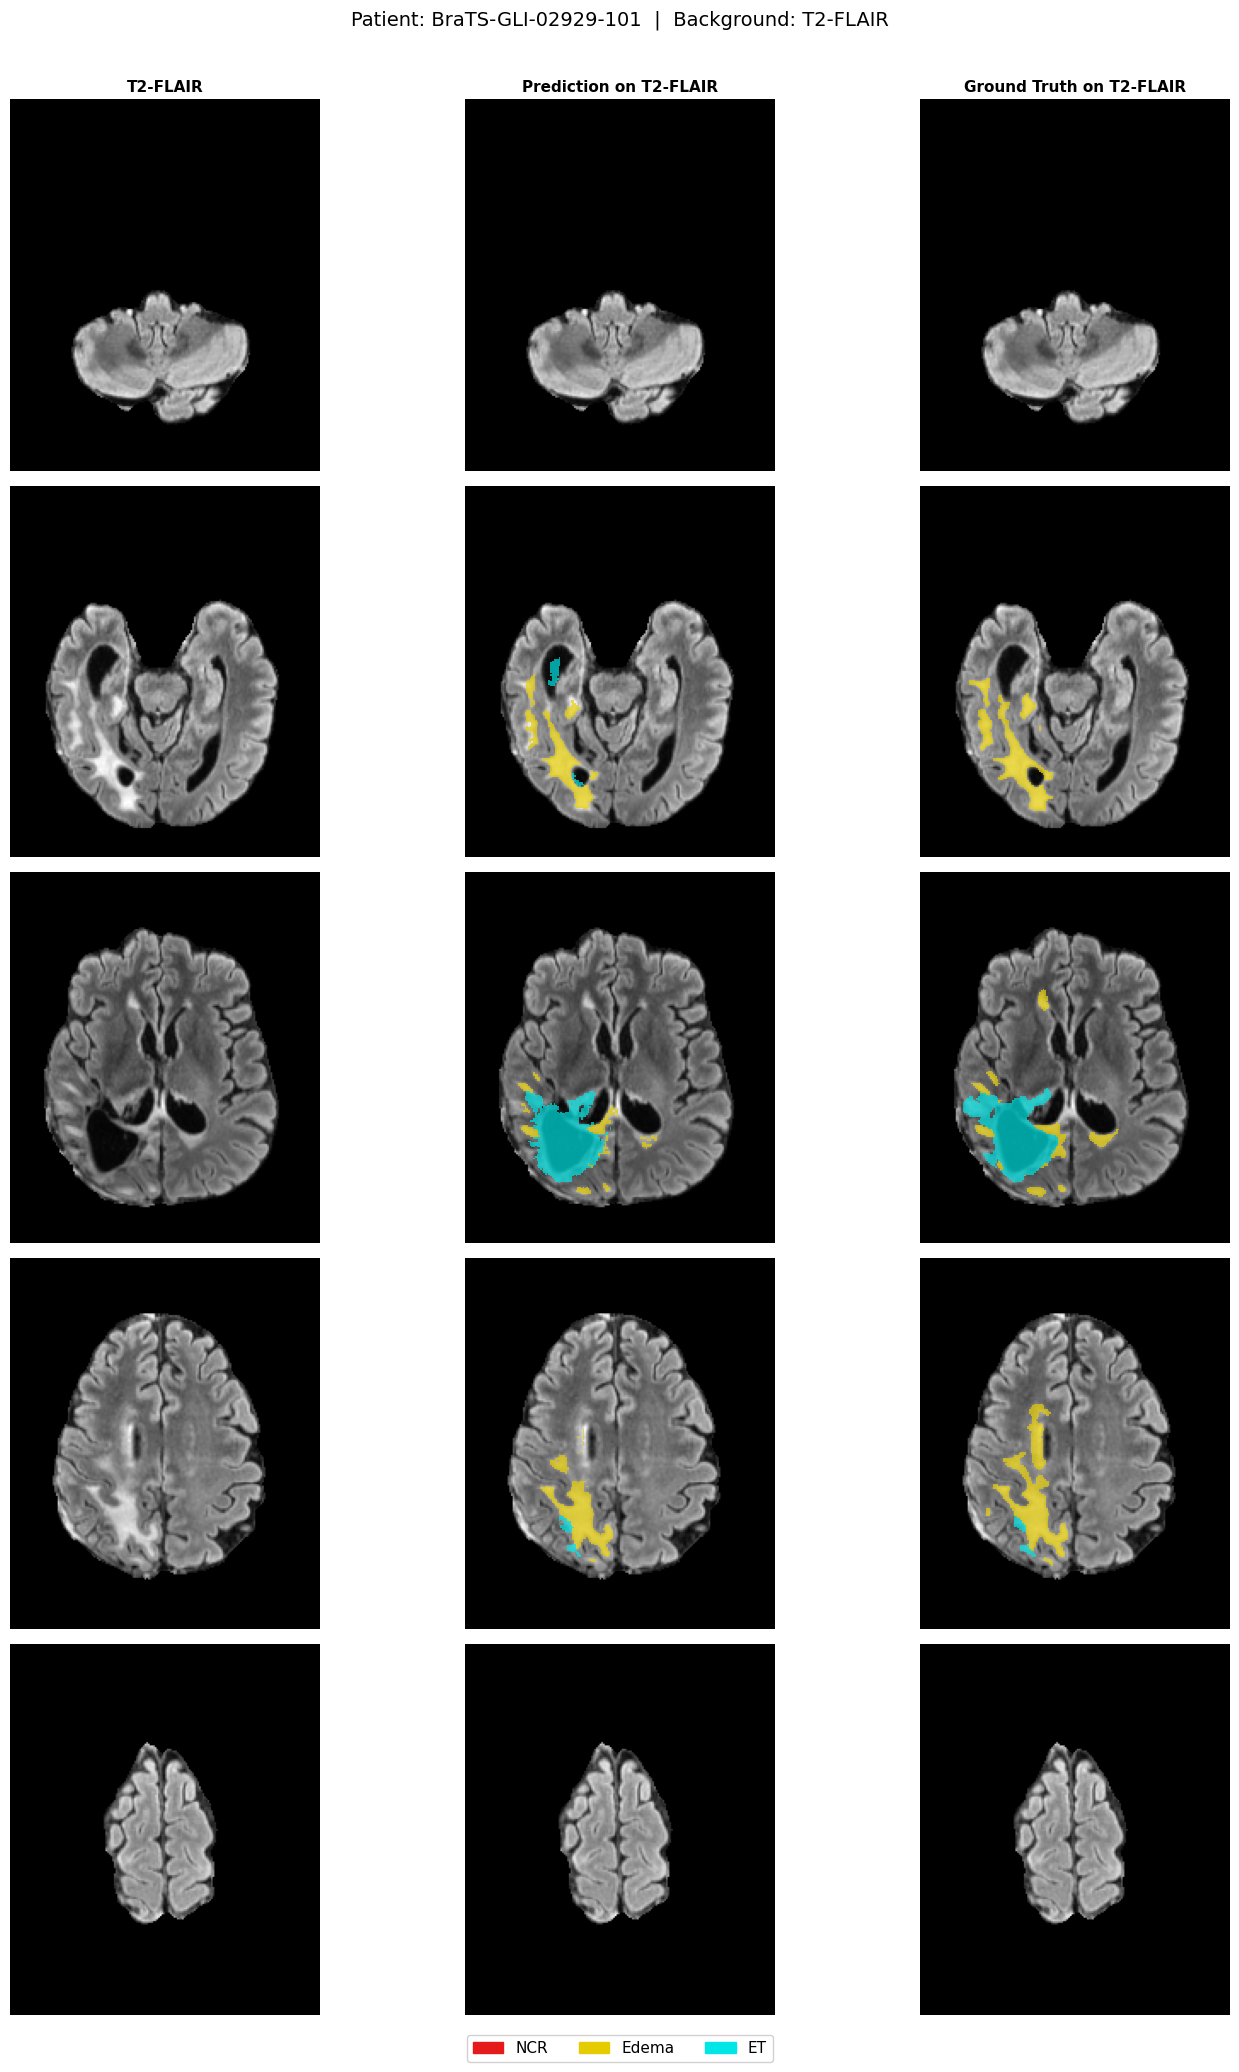

   💾 Saved: BraTS-GLI-02929-101_flair_prediction.png

  SUMMARY — Scores across all patients (T2-FLAIR view)
       patient       WT_Dice        WT_IoU       TC_Dice        TC_IoU       ET_Dice        ET_IoU
  BraTS-GLI-02929-101        0.8134        0.6855        0.6915        0.5285        0.6912        0.5282

  💾 Scores saved to: all_patients_scores.csv

  Averages:
    WT_Dice         : 0.8134
    WT_IoU          : 0.6855
    TC_Dice         : 0.6915
    TC_IoU          : 0.5285
    ET_Dice         : 0.6912
    ET_IoU          : 0.5282

✅ Done.


In [16]:
# ============================================================
# inference — run this cell
# Set the two paths below, everything prints in cell output
# ============================================================

PATIENT_DIR = r"train/BraTS-GLI-02929-101"   # ← folder for one patient
MODEL_DIR   = r"D:\shashwat\models_phase2"               # ← folder containing pkl + npy

# If you want to run on ALL patients at once, set this to the
# parent folder containing all patient sub-folders, e.g.:
#   ALL_PATIENTS_DIR = r"test"
# and set PATIENT_DIR = None
ALL_PATIENTS_DIR = None   # ← set to parent folder to batch-run, else None

# ============================================================
import numpy as np
import nibabel as nib
import joblib
import os
import gc
import glob
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import csv
from pathlib import Path
from scipy.ndimage import (uniform_filter, gaussian_filter,
                            sobel as nd_sobel,
                            label as nd_label,
                            laplace,
                            distance_transform_edt)
from skimage.filters import gabor_kernel
from sklearn.metrics import f1_score, jaccard_score

MODALITIES  = ['t1c', 't1n', 't2f', 't2w']
SEG_SUFFIX  = 'seg'
N_CLASSES   = 4
LABEL_NAMES = {0: 'Background', 1: 'NCR', 2: 'Edema', 3: 'ET'}
REGIONS     = {'WT': [1, 2, 3], 'TC': [1, 3], 'ET': [3]}
MRF_BETA       = 0.5
MRF_ITERATIONS = 5
SEG_COLORS = np.array([
    [0.0, 0.0, 0.0, 0.0],
    [0.9, 0.1, 0.1, 0.7],
    [0.9, 0.8, 0.0, 0.7],
    [0.0, 0.9, 0.9, 0.7],
], dtype=np.float32)

# ============================================================
# Collect patient directories to process
# ============================================================
if ALL_PATIENTS_DIR is not None:
    parent = Path(ALL_PATIENTS_DIR)
    patient_dirs = sorted([p for p in parent.iterdir() if p.is_dir()])
    print(f"📁 Found {len(patient_dirs)} patient folders in {ALL_PATIENTS_DIR}")
else:
    patient_dirs = [Path(PATIENT_DIR)]

# CSV log to save all scores
score_log = []   # list of dicts, one per patient

# ============================================================
# Load model ONCE outside the patient loop
# ============================================================
print(f"\n📦 Loading model from {MODEL_DIR}...")
xgb_model = joblib.load(os.path.join(MODEL_DIR, "xgb_final_phase2.pkl"))
print("   ✅ Model loaded")

cfg_path = os.path.join(MODEL_DIR, "best_config.npy")
if os.path.exists(cfg_path):
    cfg = np.load(cfg_path, allow_pickle=True).item()
    print(f"   ✅ Config loaded")
else:
    cfg = {'wt_threshold': 0.35,
           'boost': np.array([1.0, 2.5, 1.0, 2.0], np.float32)}
    print("   ⚠️  Config not found — using defaults")

print(f"   WT threshold : {cfg['wt_threshold']}")
print(f"   Boost        : {cfg['boost']}")


# ============================================================
# Helper functions
# ============================================================
def zscore(vol, mask):
    v = vol.copy()
    roi = v[mask]
    v[mask]  = (roi - roi.mean()) / (roi.std() + 1e-8)
    v[~mask] = 0.0
    return v

def fast_local_std(vol, size):
    mean  = uniform_filter(vol.astype(np.float32), size=size)
    mean2 = uniform_filter((vol**2).astype(np.float32), size=size)
    return np.sqrt(np.maximum(mean2 - mean**2, 0)).astype(np.float32)

def apply_gabor_3d(vol, kernel_2d):
    from scipy.ndimage import convolve
    return convolve(vol.astype(np.float32),
                    kernel_2d[:, :, np.newaxis],
                    mode='reflect').astype(np.float32)

def entropy_proxy(vol, size=5):
    lmean = uniform_filter(np.abs(vol).astype(np.float32), size=size)
    return (fast_local_std(vol, size) / (lmean + 1e-6)).astype(np.float32)

def distance_to_edge(mask):
    dist = distance_transform_edt(mask).astype(np.float32)
    return dist / (dist.max() + 1e-8)

def norm(img):
    mn, mx = img.min(), img.max()
    return (img - mn) / (mx - mn + 1e-8)

def label_to_rgba(lslice):
    rgba = np.zeros((*lslice.shape, 4), dtype=np.float32)
    for lbl in range(N_CLASSES):
        rgba[lslice == lbl] = SEG_COLORS[lbl]
    return rgba

gabor_kernels = [
    np.real(gabor_kernel(0.2, theta=t)).astype(np.float32)
    for t in [0, np.pi/4, np.pi/2, 3*np.pi/4]
]

_COMPAT = np.array([
    [ 0.0, -1.0, -0.5, -1.0],
    [-1.0,  0.0, -0.8,  0.0],
    [-0.5, -0.8,  0.0, -0.8],
    [-1.0,  0.0, -0.8,  0.0],
], dtype=np.float32)


# ============================================================
# Per-patient loop
# ============================================================
for patient_dir in patient_dirs:

    pid = patient_dir.name
    print(f"\n{'='*56}")
    print(f"  Processing patient: {pid}")
    print(f"{'='*56}")

    # ----------------------------------------------------------
    # STEP 1 — LOAD
    # ----------------------------------------------------------
    print("📂 Loading...")
    data   = {}
    affine = None

    for mod in MODALITIES + [SEG_SUFFIX]:
        matches = glob.glob(str(patient_dir / f"{pid}-{mod}.nii.gz"))
        if not matches:
            matches = glob.glob(str(patient_dir / f"*-{mod}.nii.gz"))
        if not matches:
            if mod == SEG_SUFFIX:
                data[mod] = None
                print(f"   {mod}: not found — Dice will be skipped")
                continue
            else:
                print(f"   ⚠️  Missing modality {mod} — skipping patient")
                break
        img        = nib.load(matches[0])
        data[mod]  = img.get_fdata(dtype=np.float32)
        if affine is None:
            affine = img.affine
        print(f"   {mod}: {data[mod].shape}")
    else:
        pass   # all modalities found, continue

    if any(mod not in data for mod in MODALITIES):
        continue   # skip this patient

    # ----------------------------------------------------------
    # STEP 2 — PREPROCESS
    # ----------------------------------------------------------
    brain_mask = np.zeros(data[MODALITIES[0]].shape, dtype=bool)
    for mod in MODALITIES:
        brain_mask |= (data[mod] > 0)
    print(f"   Brain voxels: {brain_mask.sum():,}")

    proc = {}
    for mod in MODALITIES:
        proc[mod] = zscore(data[mod], brain_mask)
    proc[SEG_SUFFIX] = data[SEG_SUFFIX]

    # ----------------------------------------------------------
    # STEP 3 — FEATURE EXTRACTION
    # ----------------------------------------------------------
    print("🔧 Extracting features...")
    cols      = []
    dist_edge = distance_to_edge(brain_mask)

    def add(vol):
        cols.append(vol[brain_mask].astype(np.float32))

    for mod in MODALITIES:
        vol = proc[mod].astype(np.float32)
        add(vol.copy())
        for sz in [3, 5, 9, 15]:
            add(uniform_filter(vol, size=sz))
            add(fast_local_std(vol, size=sz))
        gx = nd_sobel(vol, axis=0)
        gy = nd_sobel(vol, axis=1)
        gz = nd_sobel(vol, axis=2)
        add(np.sqrt(gx**2 + gy**2 + gz**2).astype(np.float32))
        del gx, gy, gz
        add(np.abs(laplace(vol)).astype(np.float32))
        g1 = gaussian_filter(vol, sigma=1.0)
        g2 = gaussian_filter(vol, sigma=2.0)
        g3 = gaussian_filter(vol, sigma=3.0)
        add(g1); add(g2); add(g3)
        add((g1 - g2).astype(np.float32))
        add((g2 - g3).astype(np.float32))
        del g1, g2, g3
        for k in gabor_kernels:
            add(apply_gabor_3d(vol, k))
        add((vol - vol[::-1, :, :]).astype(np.float32))
        add(entropy_proxy(vol))
        add(dist_edge)
        del vol
        gc.collect()

    shape = proc[MODALITIES[0]].shape
    cx, cy, cz = [s/2 for s in shape]
    xx, yy, zz = np.meshgrid(
        np.linspace(0, 1, shape[0], dtype=np.float32),
        np.linspace(0, 1, shape[1], dtype=np.float32),
        np.linspace(0, 1, shape[2], dtype=np.float32),
        indexing='ij')
    add(xx); add(yy); add(zz)
    xn = (np.arange(shape[0], dtype=np.float32) - cx) / (cx + 1e-8)
    yn = (np.arange(shape[1], dtype=np.float32) - cy) / (cy + 1e-8)
    zn = (np.arange(shape[2], dtype=np.float32) - cz) / (cz + 1e-8)
    add(np.sqrt(xn[:,None,None]**2 + yn[None,:,None]**2 + zn[None,None,:]**2
                ).astype(np.float32))
    del xx, yy, zz; gc.collect()

    eps = 1e-8
    t1c = proc['t1c'].astype(np.float32)
    t1n = proc['t1n'].astype(np.float32)
    t2f = proc['t2f'].astype(np.float32)
    t2w = proc['t2w'].astype(np.float32)
    add(np.clip(t2w / (t1c + eps), -10, 10))
    add(np.clip(t2f / (t1n + eps), -10, 10))
    add(t2f - t1c);  add(t2w - t1n);  add(t1c - t1n)
    add(t2f - t2w);  add(t1c - t2f);  add(t1c - t2w)
    add(np.clip(t1c / (t2f + eps), -10, 10))
    add(gaussian_filter((t1c - t1n).astype(np.float32), sigma=1.5))
    add(np.clip(t2f / (t2w + eps), -10, 10))
    add((t1c * t2f) / (np.abs(t1c * t2f).max() + eps))
    add((t1n * t2w) / (np.abs(t1n * t2w).max() + eps))
    del t1c, t1n, t2f, t2w; gc.collect()

    X = np.column_stack(cols).astype(np.float32)
    del cols; gc.collect()
    print(f"   Feature matrix: {X.shape}")

    # ----------------------------------------------------------
    # STEP 4 — XGBOOST INFERENCE
    # ----------------------------------------------------------
    print("🚀 Running inference...")
    BATCH = 500_000
    proba_parts = []
    for s in range(0, len(X), BATCH):
        e = min(s + BATCH, len(X))
        proba_parts.append(
            xgb_model.predict_proba(X[s:e]).astype(np.float32))
        print(f"   voxels {s:,} → {e:,} done")
    proba_flat = np.concatenate(proba_parts)
    del X; gc.collect()

    # ----------------------------------------------------------
    # STEP 5 — MRF POST-PROCESSING
    # ----------------------------------------------------------
    print("🧠 MRF smoothing...")
    proba_vol = np.zeros((N_CLASSES, *shape), dtype=np.float32)
    for c in range(N_CLASSES):
        v = np.zeros(shape, dtype=np.float32)
        v[brain_mask] = proba_flat[:, c]
        proba_vol[c]  = v

    boost = np.array(cfg['boost'], dtype=np.float32)
    proba_vol *= boost[:, None, None, None]
    proba_vol /= proba_vol.sum(axis=0, keepdims=True) + 1e-8

    unary = np.log(np.clip(proba_vol, 1e-6, 1.0))
    q     = proba_vol.copy()
    for it in range(MRF_ITERATIONS):
        q_sm = np.stack([
            gaussian_filter(q[c].astype(np.float64), sigma=1.0).astype(np.float32)
            for c in range(N_CLASSES)])
        msg   = np.einsum('cd,dxyz->cxyz', _COMPAT, q_sm)
        log_q = unary - MRF_BETA * msg
        log_q -= log_q.max(axis=0, keepdims=True)
        q      = np.exp(log_q)
        q     /= q.sum(axis=0, keepdims=True) + 1e-8
        print(f"   MRF iter {it+1}/{MRF_ITERATIONS}")
    proba_vol = q

    pred_vol = proba_vol.argmax(axis=0).astype(np.int8)
    prob_tumor = proba_vol[[1,2,3]].sum(axis=0)
    pred_vol[prob_tumor < cfg['wt_threshold']] = 0
    pred_vol[~brain_mask] = 0

    for lbl in [3, 1, 2]:
        binary = (pred_vol == lbl).astype(np.uint8)
        labeled, n_comp = nd_label(binary)
        for cid in range(1, n_comp + 1):
            if (labeled == cid).sum() < 200:
                pred_vol[labeled == cid] = 0

    del proba_flat; gc.collect()

    # ----------------------------------------------------------
    # STEP 6 — SCORES
    # ----------------------------------------------------------
    print(f"\n── Predicted voxel counts ──")
    for lbl, name in LABEL_NAMES.items():
        n = int((pred_vol == lbl).sum())
        print(f"   {lbl} {name:<12}: {n:>8,} voxels")

    patient_scores = {'patient': pid}

    if proc[SEG_SUFFIX] is not None:
        gt = proc[SEG_SUFFIX].astype(np.int8)
        gt[gt == 4] = 3
        y_true = gt[brain_mask]
        y_pred = pred_vol[brain_mask]

        print(f"\n── Dice / IoU (T2-FLAIR visualisation) ──")
        for region, labels in REGIONS.items():
            gt_r   = np.isin(y_true, labels).astype(np.uint8)
            pred_r = np.isin(y_pred, labels).astype(np.uint8)
            dice   = f1_score(gt_r, pred_r, zero_division=0)
            iou    = jaccard_score(gt_r, pred_r, zero_division=0)
            print(f"   {region}  Dice={dice:.4f}  IoU={iou:.4f}")
            patient_scores[f'{region}_Dice'] = round(dice, 4)
            patient_scores[f'{region}_IoU']  = round(iou,  4)

        print(f"\n── Per-label GT vs Pred ──")
        print(f"   {'Label':<12} {'GT':>10} {'Pred':>10}")
        for lbl, name in LABEL_NAMES.items():
            print(f"   {name:<12} {int((y_true==lbl).sum()):>10,} "
                  f"{int((y_pred==lbl).sum()):>10,}")
    else:
        for region in REGIONS:
            patient_scores[f'{region}_Dice'] = 'N/A'
            patient_scores[f'{region}_IoU']  = 'N/A'

    score_log.append(patient_scores)

    # ----------------------------------------------------------
    # STEP 7 — VISUALISE ON T2-FLAIR ONLY
    # ----------------------------------------------------------
    print("📊 Plotting (T2-FLAIR background)...")

    has_gt   = proc[SEG_SUFFIX] is not None
    # columns: FLAIR | Pred-on-FLAIR | GT-on-FLAIR (if available)
    n_cols   = 3 if has_gt else 2
    n_slices = 5

    z_indices = np.linspace(shape[2] * 0.2,
                             shape[2] * 0.8,
                             n_slices, dtype=int)

    fig, axes = plt.subplots(n_slices, n_cols,
                              figsize=(5 * n_cols, 4 * n_slices))
    # ensure axes is always 2-D
    if n_cols == 1:
        axes = axes[:, np.newaxis]

    fig.suptitle(f"Patient: {pid}  |  Background: T2-FLAIR", fontsize=14, y=1.01)

    col_titles = ['T2-FLAIR', 'Prediction on T2-FLAIR']
    if has_gt:
        col_titles.append('Ground Truth on T2-FLAIR')
    for col, title in enumerate(col_titles):
        axes[0, col].set_title(title, fontsize=11, fontweight='bold')

    for row, z in enumerate(z_indices):
        flair_sl = data['t2f'][:, :, z]      # ← T2-FLAIR background
        pred_sl  = pred_vol[:, :, z]

        # col 0 — plain FLAIR
        axes[row, 0].imshow(norm(flair_sl).T, cmap='gray', origin='lower')
        axes[row, 0].set_ylabel(f"z={z}", fontsize=9)
        axes[row, 0].axis('off')

        # col 1 — prediction overlaid on FLAIR
        axes[row, 1].imshow(norm(flair_sl).T, cmap='gray', origin='lower')
        axes[row, 1].imshow(label_to_rgba(pred_sl).transpose(1, 0, 2),
                             origin='lower', interpolation='none')
        axes[row, 1].axis('off')

        # col 2 — ground truth overlaid on FLAIR (if available)
        if has_gt:
            gt_sl = gt[:, :, z]
            axes[row, 2].imshow(norm(flair_sl).T, cmap='gray', origin='lower')
            axes[row, 2].imshow(label_to_rgba(gt_sl).transpose(1, 0, 2),
                                 origin='lower', interpolation='none')
            axes[row, 2].axis('off')

    patches = [
        mpatches.Patch(color=SEG_COLORS[1, :3], label='NCR'),
        mpatches.Patch(color=SEG_COLORS[2, :3], label='Edema'),
        mpatches.Patch(color=SEG_COLORS[3, :3], label='ET'),
    ]
    fig.legend(handles=patches, loc='lower center',
               ncol=3, fontsize=11, framealpha=0.9,
               bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout()
    plt.savefig(f"{pid}_flair_prediction.png", dpi=120, bbox_inches='tight')
    plt.show()
    print(f"   💾 Saved: {pid}_flair_prediction.png")

    # free memory before next patient
    del data, proc, pred_vol, proba_vol, brain_mask, dist_edge
    gc.collect()


# ============================================================
# STEP 8 — SUMMARY TABLE ACROSS ALL PATIENTS
# ============================================================
print(f"\n{'='*60}")
print("  SUMMARY — Scores across all patients (T2-FLAIR view)")
print(f"{'='*60}")

if score_log:
    header = list(score_log[0].keys())
    print("  " + "  ".join(f"{h:>12}" for h in header))
    for row in score_log:
        print("  " + "  ".join(f"{str(row[h]):>12}" for h in header))

    # save CSV
    csv_path = "all_patients_scores.csv"
    with open(csv_path, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=header)
        writer.writeheader()
        writer.writerows(score_log)
    print(f"\n  💾 Scores saved to: {csv_path}")

    # averages
    numeric_keys = [k for k in header if k != 'patient' and score_log[0][k] != 'N/A']
    if numeric_keys:
        print("\n  Averages:")
        for k in numeric_keys:
            vals = [row[k] for row in score_log if row[k] != 'N/A']
            print(f"    {k:<16}: {np.mean(vals):.4f}")

print("\n✅ Done.")